- Title: Bullpen Fatigue - Data Import, Cleaning, and Feature Engineering
- Authors: Doug Nolan, Josh Dinan
- Date: 26 September 2026
- Modified By: Doug Nolan
- Description: Trains a small feed-forward network (TensorFlow/Keras) per target, per the professor's Milestone 2 feedback suggesting a non-linear approach over leading with Multiple Linear Regression. Reads the appearance- level table exported by Bullpen_Fatigue_DataPrep.ipynb - this notebook does no data pulling of its own. Currently running against the 5-pitcher TEST SAMPLE from that notebook (331 rows) - this is a pipeline-validation pass, not a real result. Re-run DataPrep at full scale (170 relievers), then re-run this notebook, for numbers worth reporting.r's own early-season baseline), plus a trailing 3-appearance WHIP. No Lahman dependency.


In [1]:
import time
import warnings
import os

import numpy as np
import pandas as pd
import requests
import pybaseball as pb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf

warnings.filterwarnings('ignore')
pb.cache.enable()
tf.random.set_seed(10)
np.random.seed(10)
pd.set_option('display.max_columns', 50)

data_dir = '/Users/doug/DSC 630'
# writing in a way to only pull from api once, else use that data that is pushed to csv file
team_games_cache = os.path.join(data_dir, 'team_games_2025_cache.csv')
bullpen_workload_cache = os.path.join(data_dir, 'bullpen_workload_cache.csv')
modeling_table_path = os.path.join(data_dir, 'appearance_level_modeling_data.csv')

# Identify qualifying relief pitchers
- Season = 2025
- Games Started = 0
- Minimum Innings Pitched >= 30


In [2]:
bref_2025 = pb.pitching_stats_bref(2025)

relievers = bref_2025[(bref_2025['GS'] == 0) & (bref_2025['IP'] >= 30)].copy()
relievers = relievers[[
    'Name', 'Tm', 'Age', 'G', 'IP', 'BF', 'Pit', 'SV', 'WHIP', 'ERA', 'SO9', 'mlbID']].rename(columns={
    'Tm': 'team', 'Pit': 'season_pitches', 'BF': 'season_batters_faced', 'WHIP': 'season_whip'})

assert relievers['mlbID'].isna().sum() == 0, 'found relievers with no mlbID'
assert relievers['mlbID'].duplicated().sum() == 0, 'found duplicate mlbID rows'
relievers['mlbID'] = relievers['mlbID'].astype(int)
relievers = relievers.reset_index(drop = True)

print(f'Qualifying relievers (GS=0, IP >= 30) for 2025: {len(relievers)}')
relievers.tail(5)


Qualifying relievers (GS=0, IP >= 30) for 2025: 170


,Name,team,Age,G,IP,season_batters_faced,season_pitches,SV,season_whip,ERA,SO9,mlbID
165,Justin Wilson,Boston,37,62,50.0,212,840,NaN,1.360,3.24,10.3,458677
166,Steven Wilson,Chicago,30,59,55.1,241,978,2.0,1.301,3.42,8.3,621051
167,Cole Winn,Texas,25,33,41.2,162,619,NaN,0.960,1.51,7.6,668390
168,Jake Woodford,Arizona,28,22,36.1,170,625,3.0,1.596,6.44,5.7,663765
169,Kirby Yates,Los Angeles,38,50,41.1,178,761,3.0,1.331,5.23,11.3,489446


In [3]:
# dynamic mid season split. can't hard code a single date 
# need to count games and define first half and second half in a dynamic manner

team_ids = {
    108: "LAA", 109: "AZ", 110: "BAL", 111: "BOS", 112: "CHC", 113: "CIN", 114: "CLE",
    115: "COL", 116: "DET", 117: "HOU", 118: "KC", 119: "LAD", 120: "WSH", 121: "NYM",
    133: "ATH", 134: "PIT", 135: "SD", 136: "SEA", 137: "SF", 138: "STL", 139: "TB",
    140: "TEX", 141: "TOR", 142: "MIN", 143: "PHI", 144: "ATL", 145: "CWS", 146: "MIA",
    147: "NYY", 158: "MIL",
}

if os.path.exists(team_games_cache):
    team_games = pd.read_csv(team_games_cache)
    print(f'Loaded cached team schedule: {len(team_games)} rows')
else:
    rows = []
    for team_id, abbr in team_ids.items():
        resp = requests.get('https://statsapi.mlb.com/api/v1/schedule', params={
            'sportId': 1, 'season': 2025, 'gameType': 'R', 'teamId': team_id})
        for d in resp.json()['dates']:
            for g in d['games']:
                if g['status']['abstractGameState'] != 'Final':
                    continue
                rows.append({
                'team_id': team_id, 'team': abbr, 'game_pk': g['gamePk'],
                'date': g['officialDate'], 'game_number': g['gameNumber']})
        time.sleep(0.05)
    team_games = pd.DataFrame(rows).drop_duplicates(subset=['team_id', 'game_pk'])
    team_games = team_games.sort_values(['team_id', 'date', 'game_number'])
    team_games.to_csv(team_games_cache, index=False)
    print(f'Pulled and cached team schedules: {len(team_games)} rows')

team_games['team_game_num'] = team_games.groupby('team_id').cumcount() + 1

team_half_boundary = (
    team_games[team_games['team_game_num'] == 81][['team', 'date']]
    .rename(columns={'date': 'game_81_date'})
    .reset_index(drop=True))

print(f"Teams covered: {team_half_boundary['team'].nunique()} / 30")
print(f"game_81_date range: {team_half_boundary['game_81_date'].min()} to "
      f"{team_half_boundary['game_81_date'].max()}")

team_half_boundary.sort_values('game_81_date').head(10)


Loaded cached team schedule: 4860 rows
Teams covered: 30 / 30
game_81_date range: 2025-06-24 to 2025-06-28


,team,game_81_date
3,BOS,2025-06-24
14,ATH,2025-06-24
15,PIT,2025-06-24
5,CIN,2025-06-25
8,DET,2025-06-25
11,LAD,2025-06-25
12,WSH,2025-06-25
13,NYM,2025-06-25
19,STL,2025-06-25
21,TEX,2025-06-25


# pull statcast pitch level details , starting with 5 pitchers, will expand later
- each pitcher is going to have a pitch per row level detail here.
- split the pitches into the first half season and second half using the definitions from above


In [4]:
test_sample_n = 5
test_pitchers = relievers.sort_values('IP', ascending = False).head(test_sample_n)

season_frames = []
for _, row in test_pitchers.iterrows():
    t0 = time.time()
    df = pb.statcast_pitcher('2025-03-27', '2025-09-28', int(row['mlbID']))
    df['reliever_name'] = row['Name']
    season_frames.append(df)
    print(f'{row['Name']:<20} {len(df):>5} pitches ({time.time() - t0:.1f}s)')

statcast_raw = pd.concat(season_frames, ignore_index=True)
print(f'\nTotal test sample: {statcast_raw.shape[0]} rows across '
      f'{statcast_raw['game_pk'].nunique()} pitcher-games') 

Eduard Bazardo        1232 pitches (0.0s)
Carlos Vargas         1117 pitches (0.0s)
Jimmy Herget          1287 pitches (0.0s)
Abner Uribe           1174 pitches (0.0s)
Spencer Bivens        1298 pitches (0.0s)

Total test sample: 6108 rows across 296 pitcher-games


# Cleaning
- appearances are grouped by game_pk and not game_date, this avoids anyone who threw in a doubleheader (two games on the same date)
- creates pitcher team - to account for anyone who may have been traded - matching home team to the top of the inning data
- 

In [5]:
def clean_statcast_pitches(df: pd.DataFrame) -> pd.DataFrame:
    dupes = df.duplicated().sum()
    df = df.drop_duplicates()

    keep_cols = [ 'game_pk', 'game_date', 'pitcher', 'reliever_name', 'pitch_type',
    'release_speed', 'release_spin_rate', 'release_extension', 'api_break_x_arm',
    'arm_angle', 'home_team', 'away_team', 'inning_topbot', 'age_pit', 'p_throws',
    'pitcher_days_since_prev_game', 'events', 'delta_run_exp', 'at_bat_number', 
    'pitch_number']

    df = df[keep_cols].copy()
    df['game_date'] = pd.to_datetime(df['game_date'])
    df['pitcher_team'] = np.where(df['inning_topbot'] == 'Top', df['home_team'], df['away_team'])

    null_report = df[['release_speed', 'release_spin_rate', 'release_extension']].isna().mean().round(3)
    print(f' duplicates dropped: {dupes} | null release_speed: {null_report['release_speed']:.1%} '
          f'| null spin_rate: {null_report['release_spin_rate']:.1%} '
          f'| null extension: {null_report['release_extension']:.1%} ')

    df = df.sort_values(['pitcher', 'game_date', 'game_pk', 'at_bat_number', 'pitch_number'])
    return df


statcast_clean = clean_statcast_pitches(statcast_raw)
statcast_clean.head()
    

 duplicates dropped: 0 | null release_speed: 0.8% | null spin_rate: 1.9% | null extension: 0.8% 


,game_pk,game_date,pitcher,reliever_name,pitch_type,release_speed,release_spin_rate,release_extension,api_break_x_arm,arm_angle,home_team,away_team,inning_topbot,age_pit,p_throws,pitcher_days_since_prev_game,events,delta_run_exp,at_bat_number,pitch_number,pitcher_team
3635,778537,2025-03-29,623474,Jimmy Herget,SI,91.0,2454.0,5.2,1.39,-12.7,TB,COL,Bot,32,R,NaN,NaN,0.041,47,1,COL
3634,778537,2025-03-29,623474,Jimmy Herget,SL,86.2,2745.0,5.3,-0.08,9.5,TB,COL,Bot,32,R,NaN,field_out,-0.301,47,2,COL
3633,778537,2025-03-29,623474,Jimmy Herget,SL,85.5,2781.0,5.3,-0.08,7.0,TB,COL,Bot,32,R,NaN,NaN,0.039,48,1,COL
3632,778537,2025-03-29,623474,Jimmy Herget,SL,85.8,2772.0,4.9,-0.32,11.6,TB,COL,Bot,32,R,NaN,NaN,0.071,48,2,COL
3631,778537,2025-03-29,623474,Jimmy Herget,SI,93.3,2476.0,5.0,1.29,8.7,TB,COL,Bot,32,R,NaN,NaN,0.143,48,3,COL


## make pitch type relative to pitchers. 
## not all pitchers throw the same 3-6 pitch types (names) 
## but i want to see, which, if any, pitches deminish by pitcher
- baseline is mean release_speed / release_spin_rate / api_break_x_arm per pitch and pitch type
- at least 3 appearances and at least 5 pitches

In [6]:
baseline_appearances = 3
min_baseline_pitches = 5

def tag_appearance_number(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop(columns=['appearance_number'], errors='ignore')
    index = (
        df[['pitcher', 'game_pk', 'game_date']]
        .drop_duplicates()
        .sort_values(['pitcher', 'game_date', 'game_pk']))
    index['appearance_number'] = index.groupby('pitcher').cumcount() + 1
    return df.merge(index[['pitcher', 'game_pk', 'appearance_number']], on=['pitcher', 'game_pk'])

# statcast_clean = tag_appearance_number(statcast_clean)
statcast_clean = tag_appearance_number(statcast_clean)

baseline_window = statcast_clean[statcast_clean['appearance_number'] <= baseline_appearances]
pitch_type_baseline = (
    baseline_window.groupby(['pitcher', 'pitch_type'])
    .agg(
        n_pitches=('release_speed', 'size')
        , baseline_speed=('release_speed', 'mean')
        , baseline_spin=('release_spin_rate', 'mean')
        , baseline_break=('api_break_x_arm', 'mean')).reset_index())

pitch_type_baseline = pitch_type_baseline[pitch_type_baseline['n_pitches'] >= min_baseline_pitches]

# statcast_clean = statcast_clean.drop(
#     pitch_type_baseline[['baseline_speed', 'baseline_spin', 'baseline_break', 'velo_dev_pitch'
#                         ,'spin_dev_pitch', 'break_dev_pitch']],errors='ignore')

statcast_clean = statcast_clean.merge(
    pitch_type_baseline[['pitcher', 'pitch_type', 'baseline_speed', 'baseline_spin', 'baseline_break']],
    on=['pitcher', 'pitch_type'], how = 'left')

statcast_clean['velo_dev_pitch'] = statcast_clean['release_speed'] - statcast_clean['baseline_speed']
statcast_clean['spin_dev_pitch'] = statcast_clean['release_spin_rate'] - statcast_clean['baseline_spin']
statcast_clean['break_dev_pitch'] = statcast_clean['api_break_x_arm'] - statcast_clean['baseline_break']

covered = statcast_clean['baseline_speed'].notna().mean()
print(f'Pitch-type baseline table: {len(pitch_type_baseline)} (pitcher, pitch_type) pairs')
print(f'Share of pitches with a usable baseline: {covered:.1%}')
pitch_type_baseline.sort_values(['pitcher', 'n_pitches'], ascending=[True, False]).head(10)
    

Pitch-type baseline table: 15 (pitcher, pitch_type) pairs
Share of pitches with a usable baseline: 92.0%


,pitcher,pitch_type,n_pitches,baseline_speed,baseline_spin,baseline_break
1,623474,SL,19,84.505263,2588.842105,-0.213158
0,623474,SI,13,91.392308,2392.538462,1.264615
2,623474,ST,10,76.650000,2984.300000,-1.512000
7,660825,ST,31,81.961290,2542.258065,-1.345161
4,660825,FF,30,93.653333,2111.866667,0.510000
6,660825,SI,14,93.128571,2162.285714,1.267143
10,672841,SI,43,96.416279,2126.418605,1.229302
11,672841,SL,19,88.847368,2411.421053,-0.357895
9,672841,FC,17,91.705882,2374.352941,-0.305882
12,682842,SI,19,98.426316,2242.105263,1.151053


# Build appearance level table
- One row per pitcher, game_pk
- Keeps the fast ball only (FF / SI / FC) velocity / spin / extension average and he all-pitch-type deviation averages from the cell above
- Cumulative pitches first half and cumulative pitches second half are two separae counters
- brings in delta_run_exp as avg_delta_run_xp (run-value / performance signal)
- avg_pitcher_per_pa and baters_faced_this_game creaed from pitch_number / at_bat_number


In [19]:
out_events = { 
    'field_out': 1, 'strikeout': 1, 'force_out': 1, 'sac_fly': 1, 'sac_bunt': 1,
    'fielders_choice_out': 1,
    'double_play': 2, 'grounded_into_double_play': 2, 'strikeout_double_play': 2,
    'sac_fly_double_play': 2, 'sac_bunt_double_play':2,
    'triple_play': 3}

hit_events = {'single', 'double', 'triple', 'home_run'}
walk_events = {'walk', 'intent_walk'}
fastball_types = {'FF', 'SI', 'FC'}

def build_appearance_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (pitcher_id, game_pk), g in df.groupby(['pitcher', 'game_pk']):
        fb = g[g['pitch_type'].isin(fastball_types)]
        # off = g[~g['pitch_type']isin(fastball_types)]
        off = g[~g['pitch_type'].isin(fastball_types)]
        final_pitches = g.dropna(subset=['events'])
        outs = final_pitches['events'].map(out_events).fillna(0).sum()
        hits = final_pitches['events'].isin(hit_events).sum()
        walks = final_pitches['events'].isin(walk_events).sum()
        batters_faced = g['at_bat_number'].nunique()

        
        rows.append({
        'pitcher': pitcher_id,
        'reliever_name': g['reliever_name'].iloc[0],
        'game_pk': game_pk,
        'game_date': g['game_date'].iloc[0],
        'pitcher_team': g['pitcher_team'].iloc[0],
        'age_pit': g['age_pit'].iloc[0],
        'p_throws': g['p_throws'].iloc[0],
        'days_rest': g['pitcher_days_since_prev_game'].iloc[0],
        'appearance_number': g['appearance_number'].iloc[0],
        'pitches_this_game': len(g),
        'batters_faced_this_game': int(batters_faced),

            
        'avg_pitches_per_pa': round(len(g) / batters_faced, 1) if batters_faced else np.nan,
        # 'avg_fastball_velo': round(fb['release_speed'].mean(), 1) if len(fb) else np.nan,
        # 'avg_fastball_spin': round(fb['release_spin_rate'].mean(), 1) if len(fb) else np.nan,
        'avg_fastball_extension': round(fb['release_extension'].mean(), 2) if len(fb) else np.nan,
        'avg_arm_angle': round(fb['arm_angle'].mean(), 1)  if g['arm_angle'].notna().any() else np.nan,
        # 'avg_velo_deviation_all_pitches': round(g['velo_dev_pitch'].mean(), 2) 
        #     if g['velo_dev_pitch'].notna().any() else np.nan,
        # 'avg_spin_deviation_all_pitches': round(g['spin_dev_pitch'].mean(), 1) 
        #     if g['spin_dev_pitch'].notna().any() else np.nan,
        # 'avg_break_deviation_all_pitches': round(g['break_dev_pitch'].mean(), 2) 
        #     if g['break_dev_pitch'].notna().any() else np.nan,
        
        # 'avg_delta_run-exp': round(g['delta_run_exp'].mean(), 4) if g['delta_run_exp'].notna().any () else np.nan,
        'fastball_velo_deviation': round(fb['velo_dev_pitch'].mean(), 2) if fb['velo_dev_pitch'].notna().any() else np.nan,
        'secondary_velo_deviation': round(off['velo_dev_pitch'].mean(), 2) if off['velo_dev_pitch'].notna().any() else np.nan,
        'fastball_spin_deviation': round(fb['spin_dev_pitch'].mean(), 1) if fb['spin_dev_pitch'].notna().any() else np.nan,
        'secondary_spin_deviation': round(off['spin_dev_pitch'].mean(), 1) if off['spin_dev_pitch'].notna().any() else np.nan,
        'fastball_break_deviation': round(fb['break_dev_pitch'].mean(), 2) if fb['break_dev_pitch'].notna().any() else np.nan,
        'secondary_break_deviation': round(off['break_dev_pitch'].mean(), 2) if off['break_dev_pitch'].notna().any() else np.nan,
        'avg_delta_run_exp': round(g['delta_run_exp'].mean(), 4) if g['delta_run_exp'].notna().any() else np.nan,
    
        'outs_recorded': int(outs),
        'hits': int(hits),
        'walks': int(walks),
        })

    appearances = pd.DataFrame(rows).sort_values(['pitcher', 'game_date', 'game_pk'])
    appearances['cumulative_appearances_prior'] = appearances['appearance_number'] - 1

    appearances = appearances.merge(
        team_half_boundary, left_on='pitcher_team', right_on='team', how='left'
    ).drop(columns='team')
    appearances['half'] = np.where(
        appearances['game_date'] <= pd.to_datetime(appearances['game_81_date']), 'first', 'second')

    appearances['_fh_pitches'] = np.where(appearances['half'] == 'first',
                                          appearances['pitches_this_game'], 0)
    appearances['_sh_pitches'] = np.where(appearances['half'] == 'second',
                                          appearances['pitches_this_game'], 0)
    appearances['cumulative_pitches_first_half'] = (
        appearances.groupby('pitcher')['_fh_pitches'].cumsum() - appearances['_fh_pitches'])
    appearances['cumulative_pitches_second_half'] = (
        appearances.groupby('pitcher')['_sh_pitches'].cumsum() - appearances['_sh_pitches'])
    
    appearances = appearances.drop(columns=['_fh_pitches', '_sh_pitches'])

    return appearances


appearances = build_appearance_table(statcast_clean)
print(f'Appearance level rows : {len(appearances)}')
appearances.head(10)
    



        

Appearance level rows : 331


,pitcher,reliever_name,game_pk,game_date,pitcher_team,age_pit,p_throws,days_rest,appearance_number,pitches_this_game,batters_faced_this_game,avg_pitches_per_pa,avg_fastball_extension,avg_arm_angle,fastball_velo_deviation,secondary_velo_deviation,fastball_spin_deviation,secondary_spin_deviation,fastball_break_deviation,secondary_break_deviation,avg_delta_run_exp,outs_recorded,hits,walks,cumulative_appearances_prior,game_81_date,half,cumulative_pitches_first_half,cumulative_pitches_second_half
0,623474,Jimmy Herget,778537,2025-03-29,COL,32,R,NaN,1,17,4,4.2,5.17,-1.8,0.59,1.26,105.6,147.9,0.17,0.04,-0.0226,3,0,1,0,2025-06-26,first,0,0
1,623474,Jimmy Herget,778456,2025-04-04,COL,32,R,6.0,2,9,3,3.0,5.10,-9.4,-2.39,-0.69,-83.0,-85.7,-0.27,-0.19,-0.0719,3,0,0,1,2025-06-26,first,17,0
2,623474,Jimmy Herget,778442,2025-04-05,COL,32,R,1.0,3,16,4,4.0,5.12,6.8,0.25,-0.82,-93.5,-93.4,-0.09,0.09,-0.0110,3,1,0,2,2025-06-26,first,26,0
3,623474,Jimmy Herget,778394,2025-04-08,COL,32,R,3.0,4,22,5,4.4,5.01,2.3,0.77,1.25,114.2,107.4,-0.27,0.21,0.2353,1,3,0,3,2025-06-26,first,42,0
4,623474,Jimmy Herget,778352,2025-04-12,COL,32,R,4.0,5,21,5,4.2,5.41,10.1,1.56,1.35,-49.9,64.1,0.38,0.23,-0.0321,3,0,1,4,2025-06-26,first,64,0
5,623474,Jimmy Herget,778302,2025-04-15,COL,32,R,3.0,6,15,5,3.0,5.08,3.3,0.59,0.74,-65.0,40.7,0.23,0.00,0.0025,3,1,0,5,2025-06-26,first,85,0
6,623474,Jimmy Herget,778247,2025-04-19,COL,32,R,4.0,7,15,5,3.0,5.06,2.7,0.64,0.21,52.0,107.6,-0.07,-0.01,-0.0493,4,0,1,6,2025-06-26,first,100,0
7,623474,Jimmy Herget,778235,2025-04-20,COL,32,R,1.0,8,21,6,3.5,5.05,4.2,0.15,-0.99,32.7,151.5,-0.08,0.03,-0.0737,6,0,0,7,2025-06-26,first,115,0
8,623474,Jimmy Herget,778190,2025-04-24,COL,32,R,4.0,9,33,10,3.3,5.13,4.0,1.05,1.26,22.8,149.8,0.11,-0.03,0.0004,6,3,1,8,2025-06-26,first,136,0
9,623474,Jimmy Herget,778148,2025-04-27,COL,32,R,3.0,10,34,11,3.1,5.03,7.5,1.76,1.18,69.2,97.5,-0.20,0.20,0.0256,6,3,2,9,2025-06-26,first,169,0


# 6. Personal baseline & deviation targets
- velocity/spin/extension/arm angle are expressed as a deviation from that same pitcher's own early season baseline (first 3 appearances) - removes the between pitcher scale difference and leaves the within-pitcher trend 

In [21]:
baseline_cols = ['avg_fastball_extension', 'avg_arm_angle']
baseline = (
    appearances[appearances['appearance_number'] <= 3]
    .groupby('pitcher')[baseline_cols].mean()
    .rename(columns={c: f'baseline_{c}' for c in baseline_cols})
    .reset_index())

# drop first for ability to re-run cells
# merge * onto the columns that exist
appearances = appearances.drop(columns=[f'baseline_{c}' for c in baseline_cols], errors='ignore')
appearances = appearances.merge(baseline, on ='pitcher', how ='left')
appearances['extension_deviation'] = round(
    appearances['avg_fastball_extension'] - appearances['baseline_avg_fastball_extension'],2)

appearances['arm_angle_deviation'] = round(
    appearances['avg_arm_angle'] - appearances['baseline_avg_arm_angle'],1)

appearances[['reliever_name', 'appearance_number', 'half',
             'fastball_velo_deviation', 'secondary_velo_deviation',
             'fastball_spin_deviation', 'secondary_spin_deviation',
             'fastball_break_deviation', 'secondary_break_deviation',
             'extension_deviation', 'arm_angle_deviation']].head(10)
             

,reliever_name,appearance_number,half,fastball_velo_deviation,secondary_velo_deviation,fastball_spin_deviation,secondary_spin_deviation,fastball_break_deviation,secondary_break_deviation,extension_deviation,arm_angle_deviation
0,Jimmy Herget,1,first,0.59,1.26,105.6,147.9,0.17,0.04,0.04,-0.3
1,Jimmy Herget,2,first,-2.39,-0.69,-83.0,-85.7,-0.27,-0.19,-0.03,-7.9
2,Jimmy Herget,3,first,0.25,-0.82,-93.5,-93.4,-0.09,0.09,-0.01,8.3
3,Jimmy Herget,4,first,0.77,1.25,114.2,107.4,-0.27,0.21,-0.12,3.8
4,Jimmy Herget,5,first,1.56,1.35,-49.9,64.1,0.38,0.23,0.28,11.6
5,Jimmy Herget,6,first,0.59,0.74,-65.0,40.7,0.23,0.00,-0.05,4.8
6,Jimmy Herget,7,first,0.64,0.21,52.0,107.6,-0.07,-0.01,-0.07,4.2
7,Jimmy Herget,8,first,0.15,-0.99,32.7,151.5,-0.08,0.03,-0.08,5.7
8,Jimmy Herget,9,first,1.05,1.26,22.8,149.8,0.11,-0.03,0.00,5.5
9,Jimmy Herget,10,first,1.76,1.18,69.2,97.5,-0.20,0.20,-0.10,9.0


# Trailing WHIP (4th target)
- a single game whip is not useful . instead using a 3 appearance trailing window to smooth into a more continuous / useful variable

In [22]:
def add_trailing_whip(appearances: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    appearances = appearances.sort_values(['pitcher', 'game_date', 'game_pk']).copy()
    grouped = appearances.groupby('pitcher')
    roll_outs = grouped['outs_recorded'].rolling(window, min_periods=1).sum().reset_index(drop=True)
    roll_hits = grouped['hits'].rolling(window, min_periods=1).sum().reset_index(drop=True)
    roll_walks = grouped['walks'].rolling(window, min_periods=1).sum().reset_index(drop=True)

    roll_ip = roll_outs / 3
    appearances['trailing_whip'] = np.where(
    roll_ip > 0, ((roll_hits + roll_walks) / roll_ip).round(3), np.nan)
    return appearances

appearances = add_trailing_whip(appearances, window=3)
appearances[['reliever_name', 'appearance_number', 'half', 'outs_recorded', 'hits',
             'walks', 'trailing_whip']].head(20)

,reliever_name,appearance_number,half,outs_recorded,hits,walks,trailing_whip
0,Jimmy Herget,1,first,3,0,1,1.000
1,Jimmy Herget,2,first,3,0,0,0.500
2,Jimmy Herget,3,first,3,1,0,0.667
3,Jimmy Herget,4,first,1,3,0,1.714
4,Jimmy Herget,5,first,3,0,1,2.143
5,Jimmy Herget,6,first,3,1,0,2.143
6,Jimmy Herget,7,first,4,0,1,0.900
7,Jimmy Herget,8,first,6,0,0,0.462
8,Jimmy Herget,9,first,6,3,1,0.938
9,Jimmy Herget,10,first,6,3,2,1.500


# combined appearance level modeling table
- modeling_table is used directly below

In [24]:
feature_cols = [
    'pitcher', 'reliever_name', 'appearance_number', 'half',
    'cumulative_pitches_first_half', 'cumulative_pitches_second_half',
    'cumulative_appearances_prior', 'days_rest', 'age_pit', 'p_throws',
    'avg_delta_run_exp', 'avg_pitches_per_pa', 'batters_faced_this_game',
]
target_cols = [
    'fastball_velo_deviation', 'secondary_velo_deviation',
    'fastball_spin_deviation', 'secondary_spin_deviation',
    'fastball_break_deviation', 'secondary_break_deviation',
    'extension_deviation', 'arm_angle_deviation', 'trailing_whip',
]

modeling_table = appearances[feature_cols + target_cols].dropna(subset=target_cols, how='all')
modeling_table.to_csv(modeling_table_path, index=False)
print(f'Modeling rows (test sample): {len(modeling_table)} (also saved to {modeling_table_path})')
modeling_table.head(15)


Modeling rows (test sample): 331 (also saved to /Users/doug/DSC 630/appearance_level_modeling_data.csv)


,pitcher,reliever_name,appearance_number,half,cumulative_pitches_first_half,cumulative_pitches_second_half,cumulative_appearances_prior,days_rest,age_pit,p_throws,avg_delta_run_exp,avg_pitches_per_pa,batters_faced_this_game,fastball_velo_deviation,secondary_velo_deviation,fastball_spin_deviation,secondary_spin_deviation,fastball_break_deviation,secondary_break_deviation,extension_deviation,arm_angle_deviation,trailing_whip
0,623474,Jimmy Herget,1,first,0,0,0,NaN,32,R,-0.0226,4.2,4,0.59,1.26,105.6,147.9,0.17,0.04,0.04,-0.3,1.000
1,623474,Jimmy Herget,2,first,17,0,1,6.0,32,R,-0.0719,3.0,3,-2.39,-0.69,-83.0,-85.7,-0.27,-0.19,-0.03,-7.9,0.500
2,623474,Jimmy Herget,3,first,26,0,2,1.0,32,R,-0.0110,4.0,4,0.25,-0.82,-93.5,-93.4,-0.09,0.09,-0.01,8.3,0.667
3,623474,Jimmy Herget,4,first,42,0,3,3.0,32,R,0.2353,4.4,5,0.77,1.25,114.2,107.4,-0.27,0.21,-0.12,3.8,1.714
4,623474,Jimmy Herget,5,first,64,0,4,4.0,32,R,-0.0321,4.2,5,1.56,1.35,-49.9,64.1,0.38,0.23,0.28,11.6,2.143
5,623474,Jimmy Herget,6,first,85,0,5,3.0,32,R,0.0025,3.0,5,0.59,0.74,-65.0,40.7,0.23,0.00,-0.05,4.8,2.143
6,623474,Jimmy Herget,7,first,100,0,6,4.0,32,R,-0.0493,3.0,5,0.64,0.21,52.0,107.6,-0.07,-0.01,-0.07,4.2,0.900
7,623474,Jimmy Herget,8,first,115,0,7,1.0,32,R,-0.0737,3.5,6,0.15,-0.99,32.7,151.5,-0.08,0.03,-0.08,5.7,0.462
8,623474,Jimmy Herget,9,first,136,0,8,4.0,32,R,0.0004,3.3,10,1.05,1.26,22.8,149.8,0.11,-0.03,0.00,5.5,0.938
9,623474,Jimmy Herget,10,first,169,0,9,3.0,32,R,0.0256,3.1,11,1.76,1.18,69.2,97.5,-0.20,0.20,-0.10,9.0,1.500


# visuals - what is a good threshold for minimum innings
- grab data again, with no innings threshold to see full data 

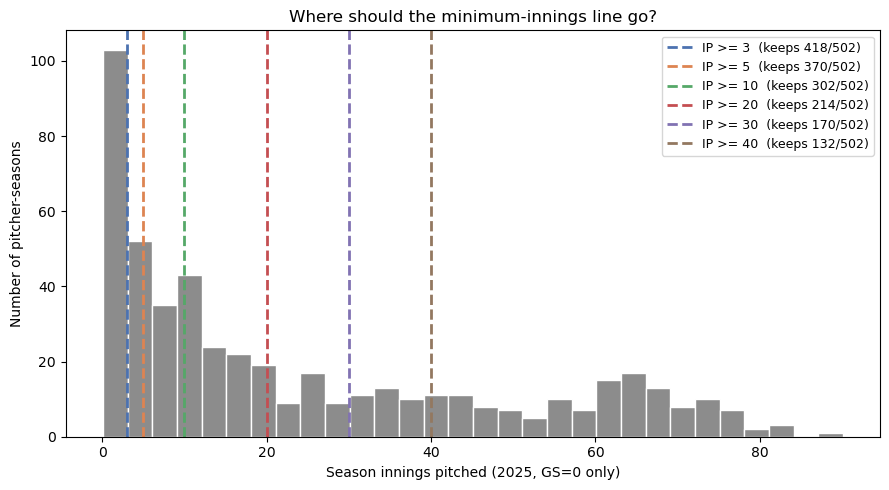

Total GS=0 pitcher-seasons: 502
Under 5 IP (likely call-up/injury noise, not a real sample): 132 (26%)


In [26]:
bref_all_relievers = pb.pitching_stats_bref(2025)
relief_unfiltered = bref_all_relievers[bref_all_relievers['GS'] == 0]

candidate_thresholds = [3, 5, 10, 20, 30, 40]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(relief_unfiltered['IP'], bins=30, color='#8C8C8C', edgecolor='white')
for cutoff, c in zip(candidate_thresholds, colors):
    n_kept = (relief_unfiltered['IP'] >= cutoff).sum()
    ax.axvline(cutoff, color=c, linestyle='--', linewidth=2,
               label=f'IP >= {cutoff}  (keeps {n_kept}/{len(relief_unfiltered)})')
ax.set_xlabel('Season innings pitched (2025, GS=0 only)')
ax.set_ylabel('Number of pitcher-seasons')
ax.set_title('Where should the minimum-innings line go?')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total GS=0 pitcher-seasons: {len(relief_unfiltered)}')
print(f'Under 5 IP (likely call-up/injury noise, not a real sample): '
      f'{(relief_unfiltered['IP'] < 5).sum()} ({(relief_unfiltered['IP'] < 5).mean():.0%})')



# Going with minimum Innings pitched of 3 helps to establish a healthy baseline of pitchers. It ignores the huge spike at 1 and 2 innings pitched, which is likely due to call-ups or injuries. 

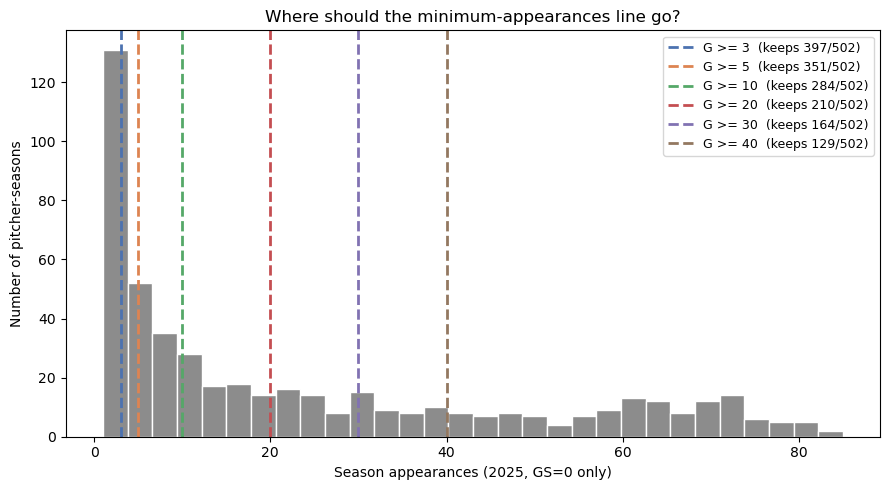

In [28]:
candidate_appearance_thresholds = [3, 5, 10, 20, 30, 40]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(relief_unfiltered['G'], bins=30, color='#8C8C8C', edgecolor='white')
for cutoff, c in zip(candidate_appearance_thresholds, colors):
    n_kept = (relief_unfiltered['G'] >= cutoff).sum()
    ax.axvline(cutoff, color=c, linestyle='--', linewidth=2,
               label=f'G >= {cutoff}  (keeps {n_kept}/{len(relief_unfiltered)})')
ax.set_xlabel('Season appearances (2025, GS=0 only)')
ax.set_ylabel('Number of pitcher-seasons')
ax.set_title('Where should the minimum-appearances line go?')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()